# Conditionals: Session 2: while loops, break/continue, and pandas categoricals

**Objectives:** By the end of this session you will be able to:
- Write a `while` loop and explain when to use it instead of a `for` loop
- Use `break` to exit a loop early and `continue` to skip an iteration
- Work with categorical data in pandas using `.unique()` and `.value_counts()`

> **Reminder:** Booleans, comparison operators, and `if/elif/else` were covered in Session 1. Refer to that notebook if you need a refresher.

## while loops

A `for` loop runs once for each item in a sequence.  
A `while` loop runs **as long as a condition stays True**; you use it when you don't know in advance how many iterations you need.

```python
while condition:
    # body; runs as long as condition is True
```

> ⚠️ **Infinite loop danger:** If the condition never becomes False, the loop runs forever. Always make sure something inside the loop moves toward making the condition False.

### ✏️ Flowchart exercise (draw on paper)

Draw a flowchart for this scenario:  
> Start at 60 °F. Keep raising the temperature by 1 degree until you reach 70 °F. Print each step.

<details>
<summary><b>Show flowchart</b> (draw yours first)</summary>

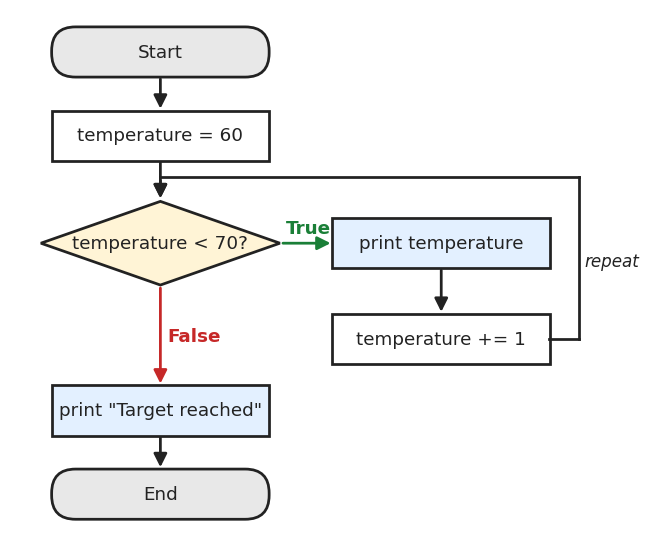

</details>

In [ ]:
temperature = 60   # starting temperature (°F)
target      = 70   # desired temperature

while temperature < target:
    print("Current temperature:", temperature, "°F, adjusting...")
    temperature += 1   # this is what moves us toward the exit condition

print("Target reached:", temperature, "°F")

### Watch a while loop run

The ventilation fan keeps running **while** the CO2 level is above 1000 ppm. Each pass through the loop the fan removes 100 ppm. Run the setup cell, then run the loop and watch the light.

`light()` works just like `print()`: give it a color, then the message. `wait()` just pauses for a moment so you can see each step.

**Try it:** change the starting `co2` to 900. What happens, and why?

In [ ]:
# @title ▶ Run this first (sets up the light)
from IPython.display import display, HTML, clear_output
import time


def light(color, *message):
    """Show a colored indicator light with a message next to it."""
    text = ' '.join(str(m) for m in message)
    html = ('<div style="display:flex;align-items:center;gap:18px;'
            'font-family:sans-serif;font-size:22px;padding:8px 0">'
            '<div style="width:64px;height:64px;border-radius:50%;'
            'background:' + color + ';box-shadow:0 0 28px ' + color + ';'
            'border:3px solid #333"></div>'
            '<b>' + text + '</b></div>')
    clear_output(wait=True)
    display(HTML(html))


def wait(seconds=0.6):
    time.sleep(seconds)


print('Light ready!')


In [ ]:
co2 = 1500   # ppm

while co2 > 1000:
    light('red', 'Fan running... CO2 =', co2, 'ppm')
    co2 -= 100
    wait()

light('limegreen', 'Air OK: CO2 =', co2, 'ppm')

## HVAC Example: Adjusting Room Temperature

A building automation system keeps adjusting an HVAC unit until the room hits the setpoint temperature.

**Your Turn #1:** write the `while` loop that keeps adjusting the room temperature until it reaches the setpoint. Print the temperature at each step, like the example above.

In [ ]:
# Your Turn #1: use a while loop to raise room_temperature by adjustment_rate
# until it reaches setpoint. Print the temperature at each step, then the final temperature
room_temperature  = 65    # °F, current reading
setpoint          = 72    # °F, desired setpoint
adjustment_rate   =  0.5  # °F per step


## Load the radon data

The `break` and `continue` examples below use the same indoor air quality (radon) readings from Session 1. Run the next two cells to load them into `iaq_df`.

In [ ]:
import pandas as pd
import requests

url = 'https://pennstateoffice365-my.sharepoint.com/:x:/g/personal/rjn5308_psu_edu/EZgpsrR5Q61CrlL0XqOmW80BnRAIYy0xJmS4X1B14sVMjg?e=E8xR91'
r = requests.get(url + '&download=1')
with open('radon.csv', 'w') as f:
    f.write(r.text)
print(r.status_code)   # 200 means the download worked

In [ ]:
iaq_df = pd.read_csv('radon.csv')
print(iaq_df.head())

## break: exit a loop early

`break` immediately stops the loop, even if the condition is still True (or there are items left).  
Use it when you've found what you were looking for and don't need to keep going.

In [ ]:
# A short list first, so you can see every step
readings = [1.2, 2.5, 4.6, 3.0, 5.1]   # pCi/L

for reading in readings:
    print("Checking", reading, "pCi/L")
    if reading > 4.0:
        print(reading, "is above 4.0, stopping")
        break

Notice that 3.0 and 5.1 were never checked. Now do the same thing with the full radon data:

In [ ]:
# lets code together
# Stop as soon as we find the first radon reading above the action level
action_level = 4.0   # pCi/L


## continue: skip one iteration

`continue` skips the rest of the current iteration and jumps to the next one.  
Use it when you want to ignore certain rows without stopping the whole loop.

In [ ]:
# A short list first, so you can see every step
readings = [1.2, 2.5, 4.6, 3.0, 5.1]   # pCi/L

for reading in readings:
    if reading <= 4:
        print("Skipping", reading, "pCi/L")
        continue
    print(reading, "pCi/L, POOR, action required")

**Your Turn #2:** loop over the radon readings and print only the POOR ones (above 4 pCi/L). Use `continue` to skip everything else.

In [ ]:
# Your Turn #2: print only the POOR readings (above 4 pCi/L)
# Use continue to skip the Good and Fair readings


## Categorical Data in pandas

A **categorical variable** has a fixed set of possible values, like building type, project status, or room classification.  
Pandas has tools specifically for working with these.

Let's load the HUD affordable housing dataset we use in class.

In [ ]:
import pandas as pd
import requests

url = 'https://pennstateoffice365-my.sharepoint.com/:x:/g/personal/rjn5308_psu_edu/ESEBzfo41jtIjrovJyKO4igBCFPET9ycHLX9LrQWwkz3qQ?e=FS9QIr'
r = requests.get(url + '&download=1')
with open('data.csv', 'w') as f:
    f.write(r.text)
print(r.status_code)   # 200 means the download worked

In [ ]:
data = pd.read_csv('data.csv')
print(data.head())

In [ ]:
# What data types do we have?
data.dtypes

Which columns look categorical (text labels with a fixed set of options) vs numeric?

In [ ]:
# lets code together
# See what unique project types exist


In [ ]:
# Your Turn #3: count how many projects of each type


Now visualize it as a bar chart:

In [ ]:
import matplotlib.pyplot as plt

counts = data['PROJECT_TYPE'].value_counts()
print(counts)

In [ ]:
fig_types, ax_types = plt.subplots(figsize=(8, 5))
ax_types.bar(counts.index, counts.values)
ax_types.set_xlabel('Project Type')
ax_types.set_ylabel('Number of Projects')
ax_types.set_title('HUD Projects by Type')
ax_types.tick_params(axis='x', rotation=15)
fig_types

## Connecting categoricals to conditionals

Start with the first 25 projects so you can check each one against the table:

In [ ]:
first_projects = data.head(25)
print(first_projects[['PROJECT_NAME', 'TOTAL_UNITS']])

In [ ]:
# lets code together
# Flag projects with a large number of units using a conditional
threshold = 50


## In-Class Assignment

Using the HUD dataset:
1. Count how many projects have `TOTAL_UNITS` > 100 using a loop and a counter variable
2. Print which `PROJECT_TYPE` appears most often (you can use `.value_counts()`)

**Submission:** Take a screengrab of your code and output and submit to Canvas.

In [ ]:
# your code here


## Extra Practice (optional)

These are **not graded** and you don't submit them. They are extra reps if you finish early or want more practice after class. Try each one yourself before you open the answer.

### Extra Practice #1: how long to cool down?

After the HVAC turns on, a server room at **80 °F** cools by **1.5 °F every hour**. Use a `while` loop to find how many hours it takes to get down to **70 °F or lower**. Print the number of hours and the final temperature.

**Hint:** keep a counter for the hours and add 1 to it each time through the loop.

In [ ]:
# Extra Practice #1


<details>
<summary><b>Show answer</b></summary>

```python
temperature = 80   # °F
hours = 0

while temperature > 70:
    temperature -= 1.5
    hours += 1
    print("Hours:", hours, "Temperature:", temperature, "°F")

print("It took", hours, "hours to reach", temperature, "°F")

# It took 7 hours to reach 69.5 °F
```

</details>

### Extra Practice #2: find the first big project

Loop over the `TOTAL_UNITS` column and find the **first** project with more than **200** units. Print its number of units, then use `break` to stop looking.

In [ ]:
# Extra Practice #2


<details>
<summary><b>Show answer</b></summary>

```python
for units in data['TOTAL_UNITS']:
    if units > 200:
        print("First project over 200 units:", units, "units")
        break

# First project over 200 units: 224.0 units
```

</details>

### Extra Practice #3: skip one project type

Loop over the `PROJECT_TYPE` column and count how many projects are **not** Homeownership. Use `continue` to skip the Homeownership projects.

**Check yourself:** compare your count with the `value_counts()` output from earlier.

In [ ]:
# Extra Practice #3


<details>
<summary><b>Show answer</b></summary>

```python
count = 0

for project_type in data['PROJECT_TYPE']:
    if project_type == 'Homeownership':
        continue   # skip this one and go to the next project
    count += 1

print("Projects that are not Homeownership:", count)

# Projects that are not Homeownership: 292  (Rental 176 + Special Needs 116)
```

</details>